# 04: 動画1本に対する匿名化のデモ

`FaceAnonymizerPipeline.anonymize_video` は，動画全体で単一の匿名化後の顔ベクトルを使用する．
すなわち，最初に顔検出できたフレームからArcFace顔ベクトルを計算し，`Anonymizer` に**1回だけ**
入力してサンプリングした顔ベクトルを，動画の全フレームに使い回す．これにより，出力動画内で
架空の人物の見た目が時間的に一貫する(フレームごとに別人に変換されることがない)．

対象とする動画のパスは `TARGET_VIDEO_PATH` を書き換えることで変更できる．


In [1]:
import os
import sys

# notebooks/ から見て1階層上がリポジトリルート
REPO_ROOT = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
os.chdir(REPO_ROOT)

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

_jp_font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
if os.path.exists(_jp_font_path):
    fm.fontManager.addfont(_jp_font_path)
    plt.rcParams["font.family"] = "Noto Sans CJK JP"
    plt.rcParams["axes.unicode_minus"] = False


In [2]:
from identity_anonymizer.faceswap import load_ghost_models, FaceAnonymizerPipeline
from identity_anonymizer.anonymizers import get_anonymizer

VAE_WEIGHT_PATH = "weights/anonymizers/vae/vae_512_128.pt"

models = load_ghost_models()
anonymizer = get_anonymizer("vae", weight_path=VAE_WEIGHT_PATH)
pipeline = FaceAnonymizerPipeline(models, anonymizer)


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(


input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
loading /home/yryo1005/workspace/identity-anonymizer/weights/ghost/2d106det 0
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)


[11:07:28] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.5.0. Attempting to upgrade...
[11:07:28] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[11:07:28] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8302 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.


In [3]:
TARGET_VIDEO_PATH = "sample_videos/sample1.mp4"  # 任意の動画パスに変更できる
OUT_DIR = "outputs/videos"
NOISE_LEVEL = 1.25

os.makedirs(OUT_DIR, exist_ok=True)
name = os.path.splitext(os.path.basename(TARGET_VIDEO_PATH))[0]
out_video_path = os.path.join(OUT_DIR, f"{name}_anonymized.mp4")

pipeline.anonymize_video(TARGET_VIDEO_PATH, out_video_path, noise_level=NOISE_LEVEL, keep_audio=True)
print("saved:", out_video_path)


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
[11:07:32] ../src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:96: Running performance tests to find the best convolution algorithm, this can take a while... (set the environment variable MXNET_CUDNN_AUTOTUNE_DEFAULT to 0 to disable)
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` n

ffmpeg が見つからないため，音声の付与をスキップしました．
saved: outputs/videos/sample1_anonymized.mp4


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: 

## 定性評価: 元動画と匿名化後動画のフレーム比較

時間的に均等な間隔で5フレームを取り出し，同一の顔ベクトルが全フレームで使われていることを
視覚的に確認する．


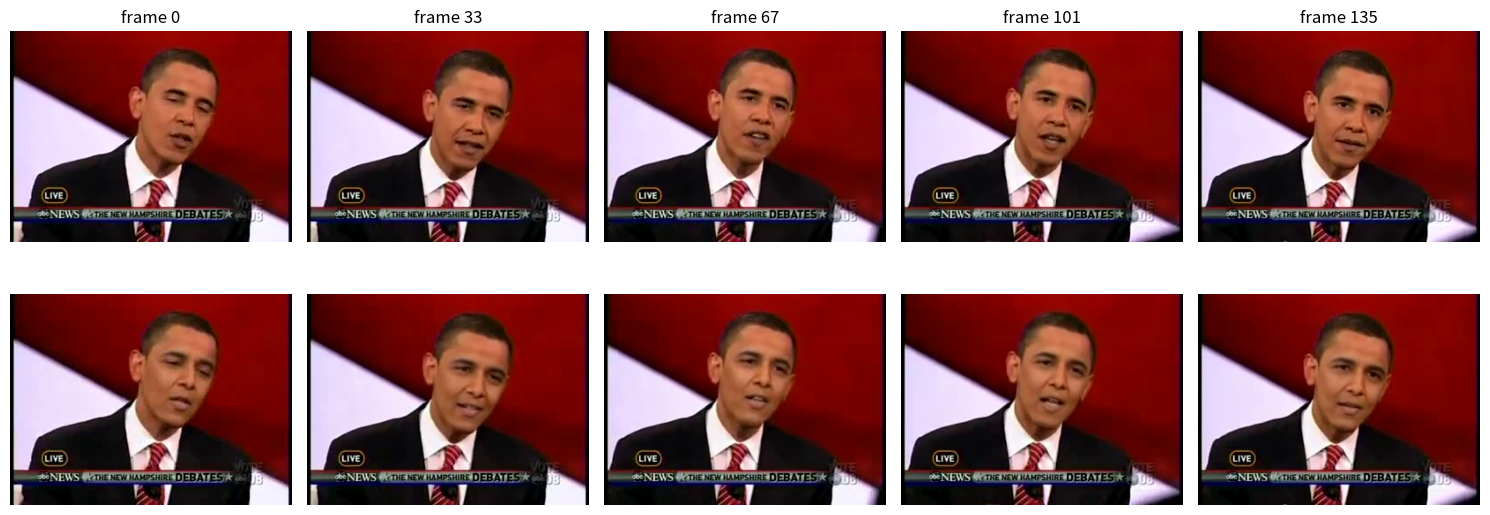

In [4]:
import numpy as np
from utils.inference.video_processing import read_video


def sample_frame_indices(num_frames: int, num_samples: int = 5):
    """
    動画のフレーム数から，時間的に均等な間隔のフレーム番号を抽出する．

    引数:
        num_frames (int): 動画の総フレーム数．
        num_samples (int): 抽出するフレーム数．
    戻り値:
        indices (list[int]): 抽出されたフレーム番号のリスト．
    """
    if num_frames <= num_samples:
        return list(range(num_frames))
    return list(np.linspace(0, num_frames - 1, num_samples).astype(int))


original_frames, _ = read_video(TARGET_VIDEO_PATH)
anonymized_frames, _ = read_video(out_video_path)

n = min(len(original_frames), len(anonymized_frames))
indices = sample_frame_indices(n, 5)

fig, axes = plt.subplots(2, len(indices), figsize=(3 * len(indices), 6))
for col, idx in enumerate(indices):
    axes[0, col].imshow(original_frames[idx][:, :, ::-1])
    axes[0, col].set_title(f"frame {idx}")
    axes[0, col].axis("off")
    axes[1, col].imshow(anonymized_frames[idx][:, :, ::-1])
    axes[1, col].axis("off")

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f"{name}_comparison.png"))
plt.show()


## 定量評価: フレーム間での顔の同一性

匿名化後動画の各フレームからArcFace顔ベクトルを再計算し，先頭フレームとのコサイン類似度を
時系列で確認する．値が1に近く安定しているほど，動画全体を通じて同一の架空の人物として
一貫して変換できていることを示す．


先頭フレームとのコサイン類似度: 平均=0.9090, 標準偏差=0.0160


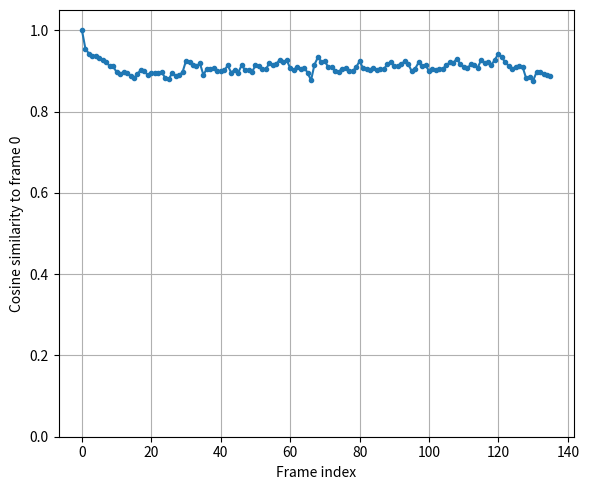

In [5]:
import cv2
import torch
import torch.nn.functional as F
from utils.inference.image_processing import crop_face, normalize_and_torch_batch


def extract_arcface_embedding(full_frame_bgr, models, crop_size=224):
    """
    フレーム画像(顔以外の背景を含む)から顔領域を検出・切り出したうえで，ArcFaceの顔ベクトル
    (単位ベクトル)を計算する．

    引数:
        full_frame_bgr (np.ndarray): 形状 (H, W, 3) のフレーム画像(BGR)．
        models: `load_ghost_models` で読み込んだモデル一式．
        crop_size (int): ArcFaceへ入力する前に顔領域をリサイズする一辺のサイズ．
    戻り値:
        embedding (np.ndarray または None): 形状 (512,) のL2正規化された顔ベクトル．
            顔が検出できない場合は None．
    """
    try:
        face = crop_face(full_frame_bgr, models.app, crop_size)[0]
    except TypeError:
        return None

    face_norm = normalize_and_torch_batch(np.array([face[:, :, ::-1]]))
    with torch.no_grad():
        embedding = models.arcface(F.interpolate(face_norm, scale_factor=0.5, mode="bilinear", align_corners=True))
        embedding = F.normalize(embedding)
    return embedding.detach().cpu().numpy()[0]


embeddings = [extract_arcface_embedding(f, pipeline.models) for f in anonymized_frames]
embeddings = np.array([e for e in embeddings if e is not None])
similarities = embeddings @ embeddings[0]

print(f"先頭フレームとのコサイン類似度: 平均={similarities.mean():.4f}, 標準偏差={similarities.std():.4f}")

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(similarities, marker="o", markersize=3)
ax.set_xlabel("Frame index")
ax.set_ylabel("Cosine similarity to frame 0")
ax.set_ylim(0, 1.05)
ax.grid()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f"{name}_identity_consistency.png"))
plt.show()
